# Multiplexing normal diffusion analysis

Cell-level normal diffusion analysis with individual and combined figures.

In [1]:
from pathlib import Path
import importlib
import sys

WORKING_DIR = Path.cwd().resolve()
MODULE_CANDIDATES = (
    WORKING_DIR,
    WORKING_DIR / "Figure_8_Multiplexing",
    WORKING_DIR / "notebooks" / "Figure_8_Multiplexing",
)
NOTEBOOK_DIR = next(
    (path for path in MODULE_CANDIDATES if (path / "multiplexing_msd.py").is_file()),
    None,
)
if NOTEBOOK_DIR is None:
    raise FileNotFoundError("Could not locate multiplexing_msd.py.")
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import multiplexing_msd
multiplexing_msd = importlib.reload(multiplexing_msd)


## Settings

In [2]:
# Input and output
RESULTS_DIR = Path('/Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_8_Multiplexing/data/final_data')
OUTPUT_DIR = NOTEBOOK_DIR / "results_normal_diffusion"
RAW_DATA_DIR = NOTEBOOK_DIR / "raw_data"
SAVE_PLOTS = True
# Keep valid units and report units made underpowered by the strict trajectory filter.
STRICT_VALIDATION = False

# Paired tracking channels
CHANNELS = (0, 1)
CHANNEL_CONDITION_LABELS = {
    0: "SunTag",
    1: r"UTag($\Delta$Cys)",
}
SOURCE_DATA_CONDITION_LABELS = {0: "SunTag", 1: "UTag_DeltaCys"}
MEASUREMENT_CHANNEL_MAP = {0: 0, 1: 1}
TRAJECTORY_REDUCER = "mean"
CELL_REDUCER = "mean"

# Trajectory acceptance
MINIMUM_TRAJECTORY_FRAMES = 10
REJECT_TRAJECTORY_GAPS = False

# Normal diffusion fit: edit the frame count only.
MAXIMUM_FIT_LAG_FRAMES = 10
MAXIMUM_FIT_LAG_SECONDS = multiplexing_msd.fit_lag_seconds_from_frames(
    RESULTS_DIR, MAXIMUM_FIT_LAG_FRAMES
)
MAXIMUM_COMPUTED_LAG_FRAMES = 15 #None
MINIMUM_CONTRIBUTORS_PER_LAG = 5
REMOVE_DRIFT = False

# Figures
PLOT_CENTER = "mean"
PLOT_UNCERTAINTY = "sem"
MSD_SCALE = "linear"
MSD_ERROR_STYLE = "band"
MSD_DISPLAY_MAX_SECONDS = None
SHOW_INDIVIDUAL_CELL_MSD = False
CONNECT_PAIRED_CELLS = False
SHOW_BOXPLOTS = True
SHOW_SAMPLE_COUNTS = False
DISPLAY_UPPER_PERCENTILE = None  # show every cell and preserve boxplot whiskers

# Figure dimensions (width, height in inches)
CELL_METRIC_FIGSIZE = (6.2, 6.2)  # Adjust to manually control metric boxplot sizes
MSD_FIGSIZE = (8.5, 6.8)          # Adjust to manually control paired MSD curve size
CELL_METRICS = [
    "D_um2_s",
    "n_trajectories",
    "median_trajectory_frames",
    "cell_spot_intensity_au",
    "cell_spot_fwhm_um",
    "cell_spot_snr",
]
CELL_YLABELS = {
    "D_um2_s": r"D ($\mu$m$^2$/s)",
    "n_trajectories": "No. trajectories per cell",
    "median_trajectory_frames": "Trajectory length (frames)",
    "cell_spot_intensity_au": "Mean spot intensity (a.u.)",
    "cell_spot_fwhm_um": r"Spot size ($\mu$m)",
    "cell_spot_snr": "Spot SNR",
}
COMBINED_PANELS = [
    "n_trajectories",
    "cell_spot_intensity_au",
    "cell_spot_fwhm_um",
    "D_um2_s",
    "msd",
]
COMBINED_YLABELS = {
    panel: CELL_YLABELS[panel] for panel in COMBINED_PANELS if panel in CELL_YLABELS
}
PLOT_STYLE = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 20,
    "text.color": "black",
    "axes.labelsize": 26,
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "axes.titlesize": 24,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "xtick.color": "black",
    "ytick.color": "black",
    "legend.fontsize": 22,
}
PLOT_DIR = OUTPUT_DIR / "plots" if SAVE_PLOTS else None


## Normal diffusion analysis

In [3]:
analysis = multiplexing_msd.analyze_final_results(
    RESULTS_DIR,
    maximum_fit_lag_seconds=MAXIMUM_FIT_LAG_SECONDS,
    maximum_computed_lag_frames=MAXIMUM_COMPUTED_LAG_FRAMES,
    minimum_trajectory_frames=MINIMUM_TRAJECTORY_FRAMES,
    reject_trajectory_gaps=REJECT_TRAJECTORY_GAPS,
    channels=CHANNELS,
    minimum_contributors_per_lag=MINIMUM_CONTRIBUTORS_PER_LAG,
    remove_drift=REMOVE_DRIFT,
    channel_condition_labels=CHANNEL_CONDITION_LABELS,
    measurement_channel_map=MEASUREMENT_CHANNEL_MAP,
    trajectory_reducer=TRAJECTORY_REDUCER,
    cell_reducer=CELL_REDUCER,
    strict=STRICT_VALIDATION,
    verbose=True,
)

paired_statistics = multiplexing_msd.compute_paired_channel_statistics(
    analysis,
    metrics=CELL_METRICS,
    channel_pair=CHANNELS,
    test="wilcoxon",
    adjust_fdr=False,
).drop(columns="p_value_fdr_bh")
analysis["paired_channel_statistics"] = paired_statistics
significant_statistics = paired_statistics[paired_statistics["p_value"] < 0.05].copy()

n_cells = analysis["cell_analysis_summary"]["global_cell_id"].nunique()
print(f"Cells: {n_cells}")
print(f"Fit interval: {MAXIMUM_FIT_LAG_FRAMES} frames = {MAXIMUM_FIT_LAG_SECONDS:g} s")

source_data_paths = multiplexing_msd.save_figure_8_def_source_tables(
    analysis,
    RAW_DATA_DIR,
    channels=CHANNELS,
    canonical_condition_labels=SOURCE_DATA_CONDITION_LABELS,
    normal_fit_max_lag_seconds=MAXIMUM_FIT_LAG_SECONDS,
)
print(f"Saved {len(source_data_paths)} Figure 8D-F source-data CSVs to {RAW_DATA_DIR}")


Loaded 23 valid result folders (0 invalid); channels=[0, 1].
Analyzed 46 cell/channel units. Trajectory totals by channel: {0: 569, 1: 1090}
Rejected 1277 trajectories shorter than 10 frames.
Final paired-channel table: 23 cells, 46 cell/channel rows, 23 complete channel sets.
Cells: 23
Fit interval: 10 frames = 10 s


## Individual figures

SNR uses MicroLive's `disk_doughnut` definition: `(mean disk − mean background doughnut) / SD of the background doughnut`. Detection values are averaged per trajectory and then per cell.

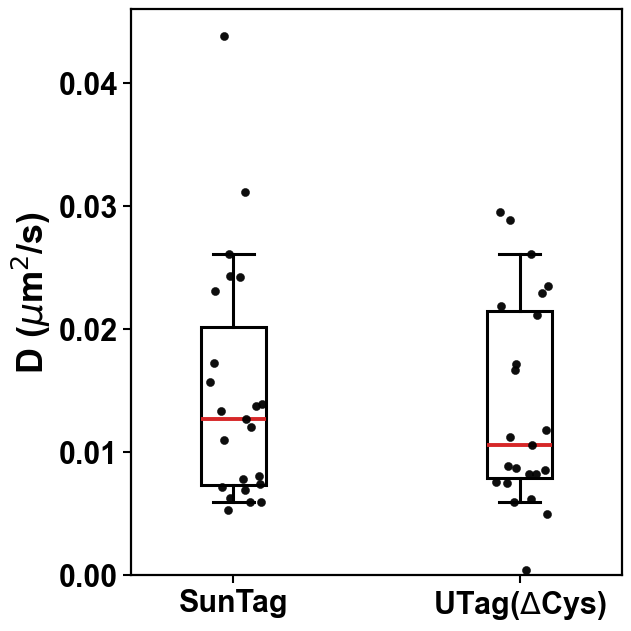

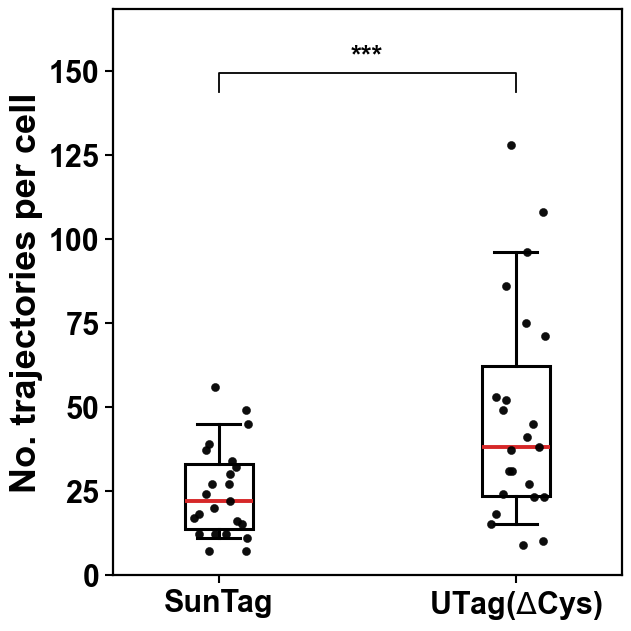

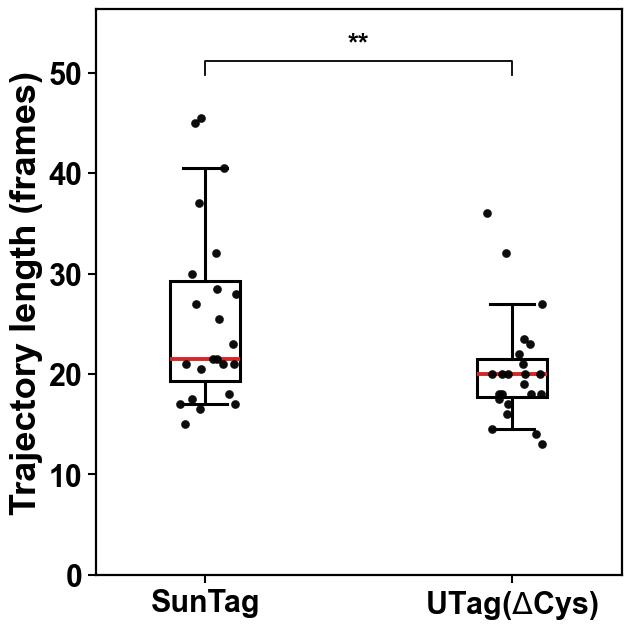

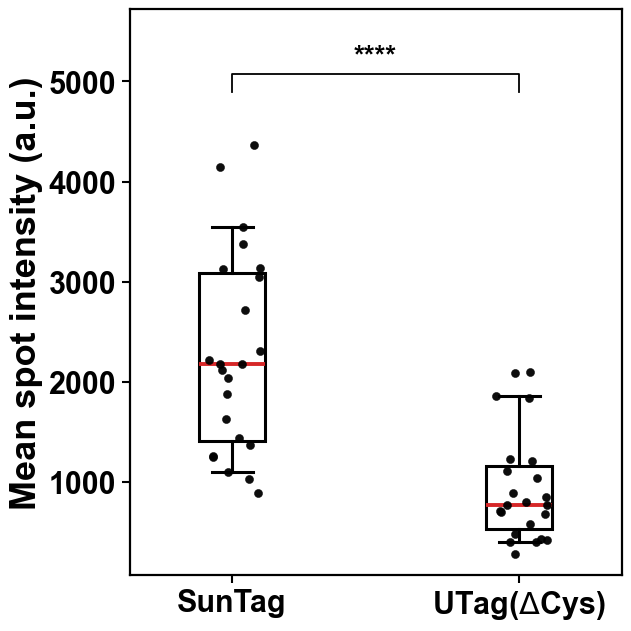

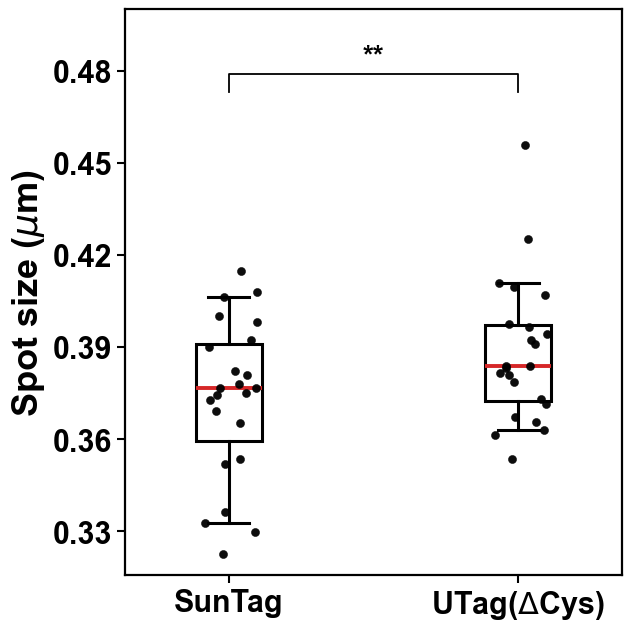

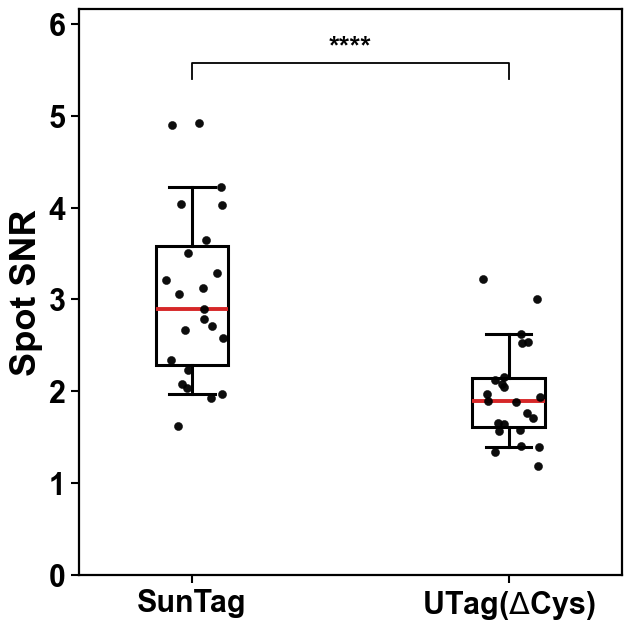

In [4]:
individual_figures = {}
for metric in CELL_METRICS:
    figure, axis, summary = multiplexing_msd.plot_cell_metric(
        analysis,
        metric=metric,
        channels=CHANNELS,
        center=PLOT_CENTER,
        uncertainty=PLOT_UNCERTAINTY,
        connect_paired_cells=CONNECT_PAIRED_CELLS,
        show_box=SHOW_BOXPLOTS,
        log_scale=None,
        display_upper_percentile=DISPLAY_UPPER_PERCENTILE,
        statistics=significant_statistics,
        statistics_label_style="stars",
        show_sample_counts=SHOW_SAMPLE_COUNTS,
        show_title=False,
        ylabel=CELL_YLABELS[metric],
        figsize=CELL_METRIC_FIGSIZE,
        plot_style=PLOT_STYLE,
        output_directory=PLOT_DIR,
        show=True,
)
    individual_figures[metric] = (figure, axis, summary)


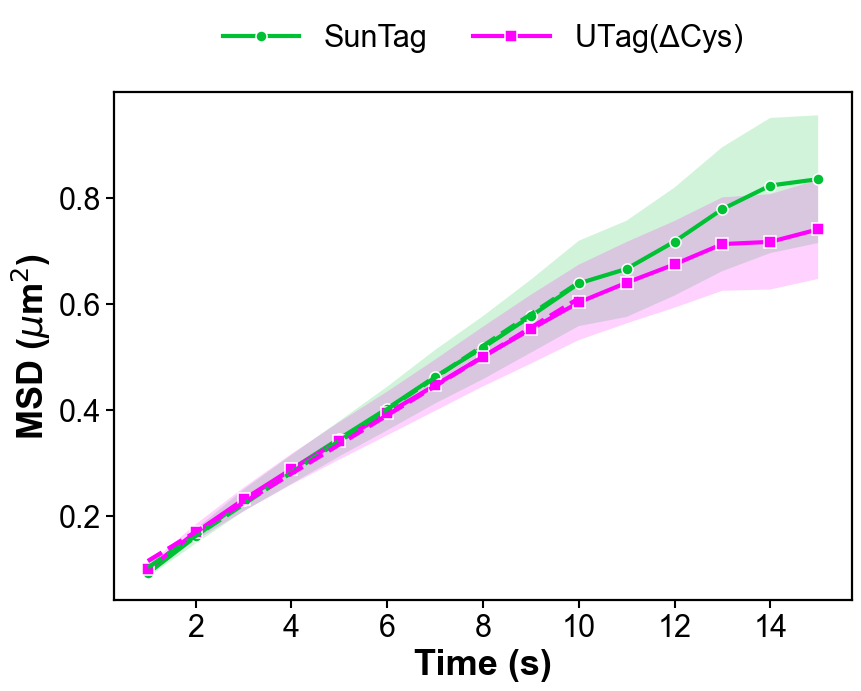

In [5]:
msd_figure, msd_axis, _ = multiplexing_msd.plot_channel_msd(
    analysis,
    channels=CHANNELS,
    center=PLOT_CENTER,
    uncertainty=PLOT_UNCERTAINTY,
    paired_cells_only=True,
    require_valid_normal_fit=True,
    show_individual_cells=SHOW_INDIVIDUAL_CELL_MSD,
    error_style=MSD_ERROR_STYLE,
    scale=MSD_SCALE,
    maximum_display_lag_seconds=MSD_DISPLAY_MAX_SECONDS,
    normal_fit_max_lag_seconds=MAXIMUM_FIT_LAG_SECONDS,
    legend_position="top",
    figsize=MSD_FIGSIZE,
    show_sample_counts=SHOW_SAMPLE_COUNTS,
    show_title=False,
    plot_style=PLOT_STYLE,
    output_directory=PLOT_DIR,
    show=True,
)


## Combined figure

In [6]:
# msd_figure, msd_axis, _ = multiplexing_msd.plot_channel_msd(
#     analysis,
#     channels=CHANNELS,
#     center=PLOT_CENTER,
#     uncertainty=PLOT_UNCERTAINTY,
#     paired_cells_only=True,
#     require_valid_normal_fit=True,
#     show_individual_cells=SHOW_INDIVIDUAL_CELL_MSD,
#     error_style=MSD_ERROR_STYLE,
#     scale=MSD_SCALE,
#     maximum_display_lag_seconds=MSD_DISPLAY_MAX_SECONDS,
#     normal_fit_max_lag_seconds=MAXIMUM_FIT_LAG_SECONDS,
#     legend_position="top",
#     figsize=MSD_FIGSIZE,
#     show_sample_counts=SHOW_SAMPLE_COUNTS,
#     show_title=False,
#     plot_style=PLOT_STYLE,
#     output_directory=PLOT_DIR,
#     show=True,
# )

## Stacked figure: cell metrics over MSD

Two cell-metric panels on the top row and the paired MSD curve underneath, on an
explicit inch grid. Panels are drawn by the same module helpers the individual
figures use, so styling, significance brackets and diffusion fits are identical;
only the placement and the type scale are set here.

In [7]:
# ---------------------------------------------------------------------------
import re
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager
from matplotlib.ticker import FormatStrFormatter, MaxNLocator, MultipleLocator


def scaled_font_sizes(scale):
    """Font rcParams scaled by `scale`, resolved against the active style.

    Every panel opens this same context, so tick labels and axis labels come out
    at one size across the figure no matter how the panels are sized. Raising
    the scale needs wider metric panels: the condition names below them are the
    first thing to collide.
    """
    keys = (
        "font.size",
        "axes.labelsize",
        "axes.titlesize",
        "xtick.labelsize",
        "ytick.labelsize",
        "legend.fontsize",
    )
    base_points = float(mpl.rcParams["font.size"])
    sizes = {}
    for key in keys:
        value = mpl.rcParams[key]
        try:
            points = float(value)
        except (TypeError, ValueError):
            points = base_points * font_manager.font_scalings.get(str(value), 1.0)
        sizes[key] = points * scale
    return sizes


def expand_svg_font_shorthand(svg_path):
    """Rewrite `font: 16px 'Arial'` as explicit font-family / font-size.

    With `svg.fonttype: 'none'` (the module default, which keeps SVG text
    editable) Matplotlib writes the CSS `font` shorthand. Illustrator ignores
    that shorthand and falls back to its own default size, so the text opens far
    too small even though the geometry is correct. Splitting it into the long
    form renders identically in browsers and Inkscape and fixes Illustrator.
    """
    pattern = re.compile(
        r"font:\s*((?:(?:italic|oblique|normal|bold|lighter|\d{3})\s+)*)"
        r"([\d.]+)px\s+([^;\"]+)"
    )

    def replace(match):
        modifiers, size, families = match.groups()
        parts = []
        for modifier in modifiers.split():
            key = "font-weight" if modifier not in {"italic", "oblique"} else "font-style"
            parts.append(f"{key}: {modifier}")
        parts.append(f"font-family: {families.strip()}")
        parts.append(f"font-size: {size}px")
        return "; ".join(parts)

    svg_path = Path(svg_path)
    text = svg_path.read_text(encoding="utf-8")
    rewritten, count = pattern.subn(replace, text)
    if count:
        svg_path.write_text(rewritten, encoding="utf-8")
    return count


def draw_metric_box_swarm(
    ax,
    analysis,
    *,
    metric,
    channels,
    statistics=None,
    statistics_label_style="stars",
    ylabel=None,
    box_width=0.55,
    whis=1.5,
    swarm_size=5.0,
    swarm_color="black",
    median_color="red",
    line_width=1.6,
    x_padding=0.62,
    bracket_height_fraction=0.10,
):
    """Box + beeswarm for one cell-level metric, drawn FRAP-figure style.

    One dot per cell, laid out by `seaborn.swarmplot` so the points spread
    symmetrically about the condition instead of landing on a random jitter.
    Whiskers are the Tukey 1.5x IQR rule, matching the FRAP panels; the module's
    own panels use 5-95 percentile whiskers instead.
    """
    labels = analysis["configuration"]["channel_condition_labels"]
    names = [str(labels[channel]) for channel in channels]
    data = multiplexing_msd._metric_valid_rows(
        analysis["cell_analysis_summary"], metric
    )
    data = data[data["channel"].isin(channels)].copy()
    if data.empty:
        raise ValueError(f"No valid cell-level values are available for {metric}.")
    data["condition"] = data["channel"].map(
        {channel: str(labels[channel]) for channel in channels}
    )

    sns.boxplot(
        data=data,
        x="condition",
        y=metric,
        order=names,
        ax=ax,
        showfliers=False,
        whis=whis,
        width=box_width,
        boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": line_width},
        medianprops={"color": median_color, "linewidth": line_width + 0.6},
        whiskerprops={"color": "black", "linewidth": line_width},
        capprops={"color": "black", "linewidth": line_width},
    )
    sns.swarmplot(
        data=data,
        x="condition",
        y=metric,
        order=names,
        ax=ax,
        color=swarm_color,
        size=swarm_size,
        linewidth=0,
        zorder=3,
    )

    if metric == "n_trajectories":
        ax.yaxis.set_major_locator(MaxNLocator(nbins=7, integer=True))
    elif metric == "D_um2_s":
        ax.yaxis.set_major_locator(MultipleLocator(0.01))
        ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    else:
        ax.yaxis.set_major_locator(MaxNLocator(nbins=7, min_n_ticks=5))
    values = data[metric].to_numpy(dtype=float)
    if multiplexing_msd.METRIC_SPECS[metric].get("zero_baseline", False) and (
        values.min() >= 0
    ):
        ax.set_ylim(bottom=0)
    ax.set_xlim(-x_padding, len(names) - 1 + x_padding)
    ax.set_xlabel("")
    ax.set_ylabel(
        str(ylabel)
        if ylabel is not None
        else multiplexing_msd.METRIC_SPECS[metric]["label"]
    )
    ax.set_title("")
    ax.set_facecolor("white")
    ax.grid(False, which="both")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(line_width)
    ax.tick_params(axis="both", which="both", colors="black")

    # Significance bracket, from the paired Wilcoxon table computed above.
    if statistics is not None and not statistics.empty and len(channels) >= 2:
        stat_row = statistics.loc[statistics["metric"] == metric]
        if not stat_row.empty:
            adjusted = "p_value_fdr_bh" in stat_row.columns
            p_column = "p_value_fdr_bh" if adjusted else "p_value"
            p_value = float(stat_row.iloc[0][p_column])
            stars = multiplexing_msd._significance_stars(p_value)
            label = (
                stars
                if statistics_label_style == "stars"
                else (
                    f"{stars}\n"
                    f"{multiplexing_msd._format_p_value(p_value, symbol='q' if adjusted else 'p')}; "
                    f"paired n = {int(stat_row.iloc[0]['n_paired_cells'])}"
                )
            )
            bottom, top = ax.get_ylim()
            span = top - bottom
            y = float(values.max()) + span * 0.06
            height = span * bracket_height_fraction * 0.25
            ax.plot(
                [0, 0, len(names) - 1, len(names) - 1],
                [y, y + height, y + height, y],
                color="black",
                linewidth=line_width * 0.8,
                clip_on=False,
            )
            ax.text(
                (len(names) - 1) / 2,
                y + height,
                label,
                ha="center",
                va="bottom",
                color="black",
                clip_on=False,
            )
            ax.set_ylim(top=max(top, y + height + span * 0.12))
    return data


def plot_metrics_over_msd(
    analysis,
    *,
    # ---------------------------------------------------------------- content
    top_metrics=("n_trajectories", "D_um2_s"),
    channels=CHANNELS,
    center=PLOT_CENTER,
    uncertainty=PLOT_UNCERTAINTY,
    statistics=None,
    statistics_label_style="stars",
    panel_ylabels=None,
    box_width=0.55,
    whis=1.5,
    swarm_size=5.0,
    msd_error_style=MSD_ERROR_STYLE,
    msd_scale=MSD_SCALE,
    msd_show_individual_cells=SHOW_INDIVIDUAL_CELL_MSD,
    show_sample_counts=SHOW_SAMPLE_COUNTS,
    maximum_display_lag_seconds=MSD_DISPLAY_MAX_SECONDS,
    normal_fit_max_lag_seconds=MAXIMUM_FIT_LAG_SECONDS,
    paired_cells_only=True,
    require_valid_normal_fit=True,
    msd_integer_time_ticks=True,   # whole-second lags read better than 2.5 / 7.5
    # ------------------------------------------------- layout, all in inches
    metric_panel_width_in=3.70,   # one top boxplot panel
    metric_panel_height_in=3.45,
    metric_gap_in=1.45,           # between the top panels (holds the right y labels)
    msd_width_in=None,            # None -> span the full width of the metric row
    msd_height_in=4.10,
    block_gap_in=0.60,            # top panels -> MSD panel
    left_gutter_in=1.35,          # y tick labels + y label of the left column
    right_margin_in=0.45,
    top_margin_in=0.45,
    bottom_gutter_in=1.15,        # MSD x tick labels + 'Time lag (s)'
    # ------------------------------------------------------------ type scale
    font_scale=1.0,              # one type scale for every panel, relative to plot_style
    font_weight="normal",         # 'normal' everywhere; the module default is semibold
    label_pad_pt=10.0,            # axis label -> tick labels; matplotlib's default 4 pt collides
    plot_style=PLOT_STYLE,
    # ----------------------------------------------------------------- output
    output_directory=PLOT_DIR,
    filename_stem="normal_diffusion_metrics_over_msd",
    formats=("png", "svg", "pdf"),
    svg_expand_font_shorthand=True,  # see expand_svg_font_shorthand()
    dpi=600,
    show=True,
):
    """Draw the metric panels and the MSD curve as one stacked figure.

    Returns ``(figure, metric_axes, msd_axis)``. The MSD panel is drawn by the
    same module helper the standalone MSD figure uses, so the curves, bands and
    diffusion fits are identical; the metric panels use the FRAP box + swarm
    style instead of the module's jittered version.
    """
    selected_channels = [int(value) for value in channels]
    if panel_ylabels is None:
        panel_ylabels = CELL_YLABELS
    if statistics is None:
        stored_statistics = analysis.get("paired_channel_statistics")
        if isinstance(stored_statistics, pd.DataFrame):
            statistics = stored_statistics

    msd_result = multiplexing_msd.build_channel_msd_summary(
        analysis,
        channels=selected_channels,
        center=center,
        uncertainty=uncertainty,
        paired_cells_only=paired_cells_only,
        require_valid_normal_fit=require_valid_normal_fit,
        maximum_display_lag_seconds=maximum_display_lag_seconds,
        normal_fit_max_lag_seconds=normal_fit_max_lag_seconds,
    )

    # ------------------------------------------------------------- inch grid
    n_metrics = len(top_metrics)
    metric_row_width_in = (
        n_metrics * metric_panel_width_in + (n_metrics - 1) * metric_gap_in
    )
    msd_width = metric_row_width_in if msd_width_in is None else float(msd_width_in)
    content_width_in = max(metric_row_width_in, msd_width)
    figure_width_in = left_gutter_in + content_width_in + right_margin_in
    msd_bottom_in = bottom_gutter_in
    metric_bottom_in = msd_bottom_in + msd_height_in + block_gap_in
    figure_height_in = metric_bottom_in + metric_panel_height_in + top_margin_in
    metric_left_in = left_gutter_in + (content_width_in - metric_row_width_in) / 2
    msd_left_in = left_gutter_in + (content_width_in - msd_width) / 2

    def axes_rect(x_in, y_in, w_in, h_in):
        """Inches measured from the bottom-left corner -> figure fraction."""
        return [
            x_in / figure_width_in,
            y_in / figure_height_in,
            w_in / figure_width_in,
            h_in / figure_height_in,
        ]

    style = dict(plot_style or {})
    style["axes.labelweight"] = font_weight
    style["axes.titleweight"] = font_weight
    with multiplexing_msd._publication_style(style):
        figure = plt.figure(
            figsize=(figure_width_in, figure_height_in), facecolor="white"
        )

        # --------------------------------------------------- top metric row
        metric_axes = []
        with mpl.rc_context(scaled_font_sizes(font_scale)):
            for index, metric in enumerate(top_metrics):
                axis = figure.add_axes(
                    axes_rect(
                        metric_left_in
                        + index * (metric_panel_width_in + metric_gap_in),
                        metric_bottom_in,
                        metric_panel_width_in,
                        metric_panel_height_in,
                    )
                )
                draw_metric_box_swarm(
                    axis,
                    analysis,
                    metric=metric,
                    channels=selected_channels,
                    statistics=statistics,
                    statistics_label_style=statistics_label_style,
                    ylabel=panel_ylabels.get(metric),
                    box_width=box_width,
                    whis=whis,
                    swarm_size=swarm_size,
                )
                metric_axes.append(axis)

        # ---------------------------------------------------------- MSD row
        with mpl.rc_context(scaled_font_sizes(font_scale)):
            msd_axis = figure.add_axes(
                axes_rect(msd_left_in, msd_bottom_in, msd_width, msd_height_in)
            )
            handles, labels = multiplexing_msd._draw_channel_msd_on_ax(
                msd_axis,
                msd_result,
                show_individual_cells=msd_show_individual_cells,
                error_style=msd_error_style,
                scale=msd_scale,
                show_sample_counts=show_sample_counts,
            )
            msd_axis.set_title("")
            if msd_integer_time_ticks and msd_scale == "linear":
                msd_axis.xaxis.set_major_locator(
                    MaxNLocator(nbins=8, integer=True, steps=[1, 2, 5, 10])
                )
            msd_axis.legend(
                handles,
                labels,
                loc="upper left",
                ncol=1,
                frameon=False,
                handlelength=2.5,
            )

        # ------------------------------------------------- label clearance
        # matplotlib's 4 pt default leaves the y label touching its own tick
        # labels at this type size; push every axis label clear of them.
        for axis in [*metric_axes, msd_axis]:
            axis.yaxis.labelpad = float(label_pad_pt)
            axis.xaxis.labelpad = float(label_pad_pt)
        figure.canvas.draw()
        renderer = figure.canvas.get_renderer()
        for axis in [*metric_axes, msd_axis]:
            tick_boxes = [
                text.get_window_extent(renderer)
                for text in axis.get_yticklabels()
                if text.get_text()
            ]
            if not tick_boxes:
                continue
            gap_in = (
                min(box.x0 for box in tick_boxes)
                - axis.yaxis.label.get_window_extent(renderer).x1
            ) / figure.dpi
            if gap_in < 0.02:
                print(
                    f"Warning: '{axis.get_ylabel()}' sits {gap_in:.3f} in from its tick "
                    "labels; raise label_pad_pt or widen the gutter."
                )

        # -------------------------------------------------------------- save
        if output_directory is not None:
            destination = Path(output_directory).expanduser().resolve()
            destination.mkdir(parents=True, exist_ok=True)
            for extension in formats:
                # No bbox_inches='tight' -- it would crop the margins and undo
                # the inch grid the panels were placed on.
                figure.savefig(
                    destination / f"{filename_stem}.{extension}",
                    dpi=dpi,
                    facecolor="white",
                    edgecolor="white",
                    transparent=False,
                )
            if svg_expand_font_shorthand and "svg" in formats:
                expand_svg_font_shorthand(destination / f"{filename_stem}.svg")
            print(f"Saved {filename_stem}.{'/'.join(formats)} to {destination}")
        print(
            f"Figure canvas: {figure_width_in:.2f} x {figure_height_in:.2f} in "
            f"(aspect {figure_width_in / figure_height_in:.3f})"
        )
        if show:
            plt.show()
        else:
            plt.close(figure)
    return figure, metric_axes, msd_axis

Saved normal_diffusion_metrics_over_msd.png/svg/pdf to /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_8_Multiplexing/results_normal_diffusion/plots
Figure canvas: 10.65 x 9.75 in (aspect 1.092)


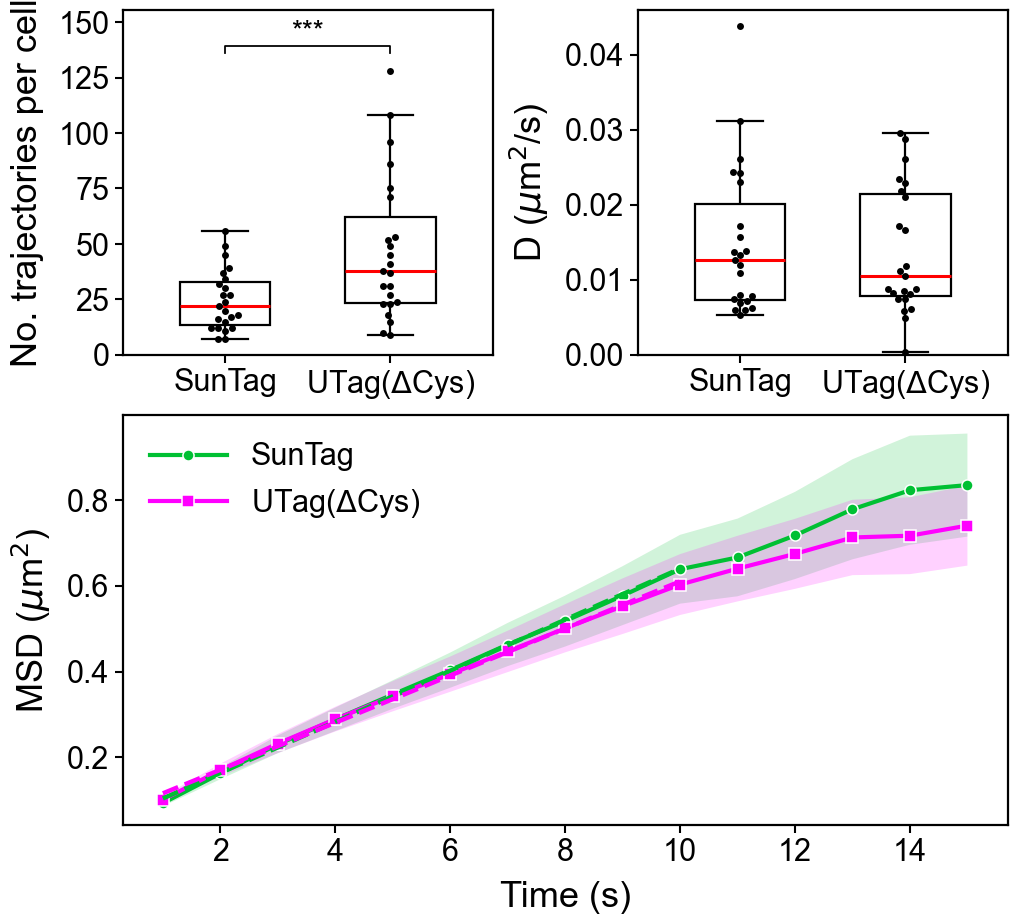

In [8]:
stacked_figure, stacked_metric_axes, stacked_msd_axis = plot_metrics_over_msd(
    analysis,
    top_metrics=("n_trajectories", "D_um2_s"),
    statistics=significant_statistics,
    output_directory=PLOT_DIR,
    show=True,
)